 # Predicción temporal de zonas y horarios de riesgo

In [1]:
from tensorflow import random as tf_random
import random
import numpy as np
import sys
sys.path.append('../')
random.seed(777)
np.random.seed(777)
tf_random.set_seed(777)
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.preprocessing.sequence import TimeseriesGenerator
from sklearn.metrics import mean_squared_error, mean_absolute_error
from src.utils.agrupar_infrecuentes import agrupar_infrecuentes
from src.utils.obtener_variables_climaticas import obtener_variables_climaticas
from src.utils.fechas import crear_ciclos, crear_variables_temporales, rellenar_zona

df = pd.read_html('../data/raw/Estadisticas.ods')[0] # Datos desde 01-01-2023 hasta el 10 de abril del 2026
print(df.shape)
df.head(3)

(142781, 12)


,Delito,SubDelito,Fecha,Hora,Victima,SubVictima,Edad,Sexo,Nacionalidad,Provincia,Canton,Distrito
0,ASALTO,ARMA BLANCA,2023-01-01,09:00:00 - 11:59:59,PERSONA,PEATON [PERSONA],Mayor de edad,HOMBRE,VENEZUELA,SAN JOSE,SAN JOSE,MERCED
1,ASALTO,ARMA BLANCA,2023-01-03,03:00:00 - 05:59:59,PERSONA,PEATON [PERSONA],Mayor de edad,HOMBRE,COSTA RICA,SAN JOSE,SAN JOSE,HOSPITAL
2,ASALTO,ARMA BLANCA,2023-01-03,12:00:00 - 14:59:59,PERSONA,PEATON [PERSONA],Mayor de edad,HOMBRE,COSTA RICA,LIMON,SIQUIRRES,SIQUIRRES


## Preprocesamiento

In [2]:
df['Hora'] = df['Hora'].str.split(':').str[0].astype(int)
df =  df.sort_values(['Fecha', 'Hora'])
df.head(2)

,Delito,SubDelito,Fecha,Hora,Victima,SubVictima,Edad,Sexo,Nacionalidad,Provincia,Canton,Distrito
250,ASALTO,ARMA BLANCA,2023-01-01,0,PERSONA,PEATON [PERSONA],Mayor de edad,HOMBRE,COSTA RICA,PUNTARENAS,GARABITO,JACO
399,ASALTO,ARMA BLANCA,2023-01-01,0,PERSONA,PEATON [PERSONA],Menor de edad,MUJER,COSTA RICA,SAN JOSE,SAN JOSE,URUCA


In [3]:
df.info()

<class 'pandas.DataFrame'>
Index: 142781 entries, 250 to 8541
Data columns (total 12 columns):
 #   Column        Non-Null Count   Dtype
---  ------        --------------   -----
 0   Delito        142781 non-null  str  
 1   SubDelito     142781 non-null  str  
 2   Fecha         142781 non-null  str  
 3   Hora          142781 non-null  int64
 4   Victima       142781 non-null  str  
 5   SubVictima    142781 non-null  str  
 6   Edad          142781 non-null  str  
 7   Sexo          142781 non-null  str  
 8   Nacionalidad  142781 non-null  str  
 9   Provincia     142781 non-null  str  
 10  Canton        142781 non-null  str  
 11  Distrito      142781 non-null  str  
dtypes: int64(1), str(11)
memory usage: 14.2 MB


El set de datos no posee valores nulos, en su lugar, ya estan codificados como 'Desconocido'

In [4]:
df.describe()

,Hora
count,142781.000000
mean,10.606411
std,7.330561
min,0.000000
25%,3.000000
50%,12.000000
75%,18.000000
max,21.000000


In [5]:
df.describe(include='str')

,Delito,SubDelito,Fecha,Victima,SubVictima,Edad,Sexo,Nacionalidad,Provincia,Canton,Distrito
count,142781,142781,142781,142781,142781,142781,142781,142781,142781,142781,142781
unique,6,39,1166,5,91,4,3,117,8,85,395
top,HURTO,POR DESCUIDO,2023-10-28,PERSONA,PEATON [PERSONA],Mayor de edad,HOMBRE,COSTA RICA,SAN JOSE,SAN JOSE,CATEDRAL
freq,47269,25314,219,56815,33585,117118,86424,109821,54589,29741,5095


A continuacion se agrupan los registros segun zona y hora. De esta manera es posible conocer el total de delitos ocurridos

In [6]:
group_cols = ['Fecha', 'Hora' ,'Provincia']
other_cols = [col for col in df.columns if col not in group_cols]

moda = lambda x: x.value_counts().index[0]

agg_dict = {col: (col, moda) for col in other_cols}
agg_dict['Conteo'] = (other_cols[0], 'count')

df_agrupado = df.groupby(group_cols).agg(**agg_dict).reset_index()
print(df_agrupado.shape)
df_agrupado.head(5)

(48411, 13)


,Fecha,Hora,Provincia,Delito,SubDelito,Victima,SubVictima,Edad,Sexo,Nacionalidad,Canton,Distrito,Conteo
0,2023-01-01,0,ALAJUELA,HURTO,POR CONFIANZA,VIVIENDA,NO APLICA [VIVIENDA],Mayor de edad,HOMBRE,COSTA RICA,ALAJUELA,FORTUNA,5
1,2023-01-01,0,CARTAGO,ASALTO,ARREBATO,PERSONA,OTRO O INDETERMINADO [PERSONA],Mayor de edad,HOMBRE,COSTA RICA,EL GUARCO,SAN ISIDRO,8
2,2023-01-01,0,GUANACASTE,HURTO,POR DESCUIDO,PERSONA,PEATON [PERSONA],Mayor de edad,HOMBRE,COSTA RICA,SANTA CRUZ,TAMARINDO,18
3,2023-01-01,0,HEREDIA,HURTO,POR DESCUIDO,PERSONA,PEATON [PERSONA],Mayor de edad,HOMBRE,COSTA RICA,HEREDIA,SAN PABLO,8
4,2023-01-01,0,LIMON,HURTO,CARTERISTA,PERSONA,NO APLICA [VIVIENDA],Mayor de edad,HOMBRE,COSTA RICA,MATINA,CAHUITA,9


El set de datos no incluye las horas en las que no ocurrieron delitos. Por lo tanto, se añade manualmente el momento en el que no paso ningun crimen para que el modelo entienda la relacion. Se rellenan los campos nulos generados con el valor 'Sin delitos'

In [7]:
df_completo = rellenar_zona(df_agrupado[df_agrupado['Provincia'] == 'CARTAGO'].drop(columns='Provincia'))
df_completo.head(3)

,Fecha,Hora,Delito,SubDelito,Victima,SubVictima,Edad,Sexo,Nacionalidad,Canton,Distrito,Conteo
0,2023-01-01,0,ASALTO,ARREBATO,PERSONA,OTRO O INDETERMINADO [PERSONA],Mayor de edad,HOMBRE,COSTA RICA,EL GUARCO,SAN ISIDRO,8
1,2023-01-01,3,Sin delitos,Sin delitos,Sin delitos,Sin delitos,Sin delitos,Sin delitos,Sin delitos,Sin delitos,Sin delitos,0
2,2023-01-01,6,Sin delitos,Sin delitos,Sin delitos,Sin delitos,Sin delitos,Sin delitos,Sin delitos,Sin delitos,Sin delitos,0


Algunas columnas como la de `Nacionalidad` y `Canton` poseen demasiadas clases. Se intenta reducir el ruido agrupando las categorias mas infrecuentes

In [8]:
umbrales = {
    'Nacionalidad': 0.03,
    'Canton': 0.05,
}

df_completo = agrupar_infrecuentes(df_completo, umbrales)

El siguiente grafico muestra que la autocorrelacion de la variable `Conteo` con el lag #8 es el mas fuerte, el cual corresponde a 24h antes

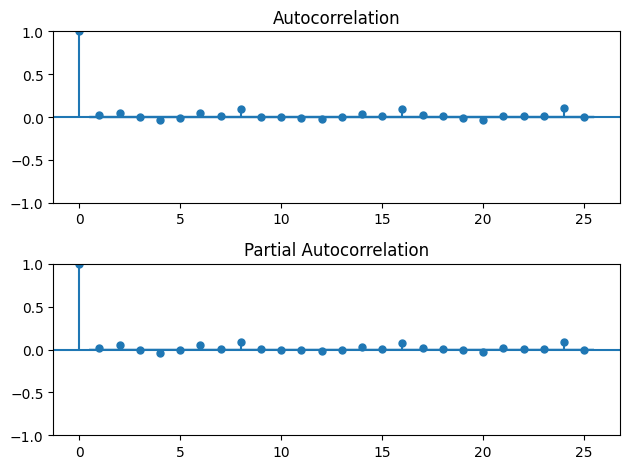

In [9]:
fig, axes = plt.subplots(2, 1)
plot_acf(df_completo['Conteo'], lags=25, ax=axes[0])
plot_pacf(df_completo['Conteo'], lags=25, ax=axes[1])
plt.tight_layout()
plt.show()

Se divide la fecha en columnas de mes, dia, año y se le añaden las columnas binarias de `fin_semana` y `es_festivo`

In [10]:
df_completo = crear_variables_temporales(df_completo, shift=9)
print(df_completo.shape)
df_completo.head(3)

(9319, 20)


,Fecha,Hora,Delito,SubDelito,Victima,SubVictima,Edad,Sexo,Nacionalidad,Canton,Distrito,Conteo,Mes,Anio,dia,dia_sem,fin_semana,es_festivo,lag_conteo1,lag_conteo9
9,2023-01-02,3,Sin delitos,Sin delitos,Sin delitos,Sin delitos,Sin delitos,Sin delitos,Sin delitos,Sin delitos,Sin delitos,0,1,2023,2,0,False,False,1.0,8.0
10,2023-01-02,6,ROBO,FORZADURA,EDIFICACION,OTRO O INDETERMINADO [EDIFICACION],Desconocido,DESCONOCIDO,COSTA RICA,CARTAGO,DULCE NOMBRE,1,1,2023,2,0,False,False,0.0,0.0
11,2023-01-02,9,Sin delitos,Sin delitos,Sin delitos,Sin delitos,Sin delitos,Sin delitos,Sin delitos,Sin delitos,Sin delitos,0,1,2023,2,0,False,False,1.0,0.0


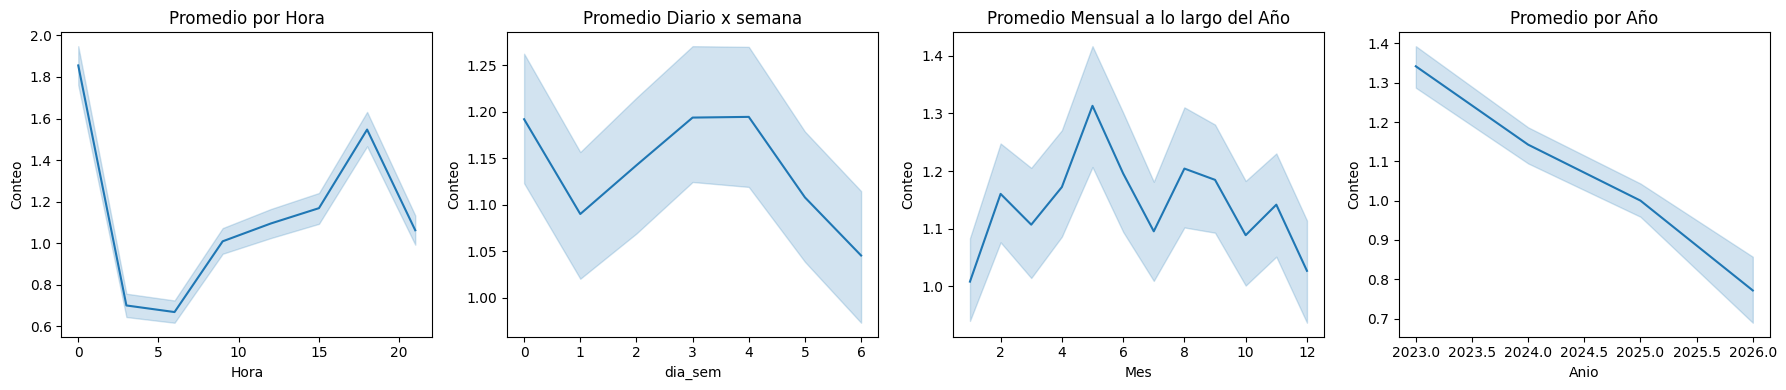

In [11]:
fig, axes = plt.subplots(1, 4, figsize=(18, 4))

sns.lineplot(data=df_completo, x='Hora',    y='Conteo', ax=axes[0])
sns.lineplot(data=df_completo, x='dia_sem', y='Conteo', ax=axes[1])
sns.lineplot(data=df_completo, x='Mes',     y='Conteo', ax=axes[2])
sns.lineplot(data=df_completo, x='Anio',    y='Conteo',  ax=axes[3])

axes[0].set_title('Promedio por Hora')
axes[1].set_title('Promedio Diario x semana')
axes[2].set_title('Promedio Mensual a lo largo del Año')
axes[3].set_title('Promedio por Año')
plt.tight_layout();

E grafico anterior muestra como se comporta el total de delitos a lo largo del tiempo. Se muestra una marcada tendencia mensual y horaria. Razon por la cual a continuacion se codifican ciclicamente esas variables:

In [12]:
df_completo = crear_ciclos(df_completo)
df_completo.head(2)

,Fecha,Delito,SubDelito,Victima,SubVictima,Edad,Sexo,Nacionalidad,Canton,Distrito,...,dia,dia_sem,fin_semana,es_festivo,lag_conteo1,lag_conteo9,hora_sin,hora_cos,Mes_sin,Mes_cos
9,2023-01-02,Sin delitos,Sin delitos,Sin delitos,Sin delitos,Sin delitos,Sin delitos,Sin delitos,Sin delitos,Sin delitos,...,2,0,False,False,1.0,8.0,0.866025,0.5,0.5,0.866025
10,2023-01-02,ROBO,FORZADURA,EDIFICACION,OTRO O INDETERMINADO [EDIFICACION],Desconocido,DESCONOCIDO,COSTA RICA,CARTAGO,DULCE NOMBRE,...,2,0,False,False,0.0,0.0,0.866025,-0.5,0.5,0.866025


Se consulta a la api de open meteo para consultar las variables climaticas de la provincia seleccionada

In [13]:
provincias_coordenadas= {
    "SAN JOSE": {"lat": 9.9281, "lon": -84.0907},
    "ALAJUELA": {"lat": 10.0162, "lon": -84.2116},
    "CARTAGO": {"lat": 9.8644, "lon": -83.9194},
    "HEREDIA": {"lat": 9.9985, "lon": -84.1165},
    "GUANACASTE": {"lat": 10.6346, "lon": -85.4407},
    "PUNTARENAS": {"lat": 9.9763, "lon": -84.8384},
    "LIMON": {"lat": 9.9907, "lon": -83.0350}
}


vars_climaticas = obtener_variables_climaticas(
    latitude=provincias_coordenadas["CARTAGO"]["lat"],
    longitude=provincias_coordenadas["CARTAGO"]["lon"],
    start_date=df_completo['Fecha'].min().strftime('%Y-%m-%d'),
    end_date=df_completo['Fecha'].max().strftime('%Y-%m-%d'),
    variables=["precipitation", "apparent_temperature",'sunshine_duration'],
    interval_hours=3
)

In [14]:
df_final = pd.concat([df_completo.reset_index(drop=True), vars_climaticas[:-1].reset_index(drop=True)], axis=1)
df_final.head(2)

,Fecha,Delito,SubDelito,Victima,SubVictima,Edad,Sexo,Nacionalidad,Canton,Distrito,...,es_festivo,lag_conteo1,lag_conteo9,hora_sin,hora_cos,Mes_sin,Mes_cos,precipitation,apparent_temperature,sunshine_duration
0,2023-01-02,Sin delitos,Sin delitos,Sin delitos,Sin delitos,Sin delitos,Sin delitos,Sin delitos,Sin delitos,Sin delitos,...,False,1.0,8.0,0.866025,0.5,0.5,0.866025,0.0,14.100000,0.0
1,2023-01-02,ROBO,FORZADURA,EDIFICACION,OTRO O INDETERMINADO [EDIFICACION],Desconocido,DESCONOCIDO,COSTA RICA,CARTAGO,DULCE NOMBRE,...,False,0.0,0.0,0.866025,-0.5,0.5,0.866025,0.0,13.066667,0.0


Finalmente se eliminan variable con poco aporte y con demasiadas categorias y se pasa a dummies:

In [15]:
df_final = pd.get_dummies(df_final.drop(columns=['Distrito', 'SubDelito','SubVictima','Fecha','dia']))

## Prediccion

In [16]:
ventana   = 9 # 24h
test_size = 240 # 30 dias

early_stop = EarlyStopping(
    monitor='val_loss', patience=15,
    restore_best_weights=True, verbose=1
)

### Usando la estructura sugerida

In [17]:
X_raw = df_final.drop(columns=['Conteo']).values
y_raw = df_final['Conteo'].values.reshape(-1, 1)

n_raw     = len(X_raw)

remaining = n_raw - test_size
train_end = int(remaining * 0.80)

X_train_raw = X_raw[:train_end]
X_val_raw   = X_raw[train_end:remaining]
X_test_raw  = X_raw[remaining:]

y_train_raw = y_raw[:train_end]
y_val_raw   = y_raw[train_end:remaining]
y_test_raw  = y_raw[remaining:]

scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()

X_train_sc = scaler_X.fit_transform(X_train_raw)
y_train_sc = scaler_y.fit_transform(y_train_raw)

X_val_sc   = scaler_X.transform(X_val_raw)
y_val_sc   = scaler_y.transform(y_val_raw)

X_test_sc  = scaler_X.transform(X_test_raw)
y_test_sc  = scaler_y.transform(y_test_raw)

train_gen = TimeseriesGenerator(
    X_train_sc, y_train_sc,
    length=ventana,
    batch_size=32
)

val_gen = TimeseriesGenerator(
    X_val_sc, y_val_sc,
    length=ventana,
    batch_size=32
)

test_gen = TimeseriesGenerator(
    X_test_sc, y_test_sc,
    length=ventana,
    batch_size=32
)

modelo1 = Sequential([
    LSTM(100, return_sequences=True, input_shape=(ventana, X_train_sc.shape[1])),
    LSTM(50),
    Dropout(0.2),
    Dense(1, activation='softplus')
])

modelo1.compile(optimizer='adam', loss='mae', metrics=['mae'])

history1 = modelo1.fit(
    train_gen,
    validation_data=val_gen,
    epochs=60,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/60


c:\Users\mecag\.pyenv\pyenv-win\versions\3.11.9\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


227/227 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 0.0820 - mae: 0.0820 - val_loss: 0.0613 - val_mae: 0.0613
Epoch 2/60
227/227 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0709 - mae: 0.0709 - val_loss: 0.0626 - val_mae: 0.0626
Epoch 3/60
227/227 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0708 - mae: 0.0708 - val_loss: 0.0626 - val_mae: 0.0626
Epoch 4/60
227/227 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0705 - mae: 0.0705 - val_loss: 0.0608 - val_mae: 0.0608
Epoch 5/60
227/227 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0703 - mae: 0.0703 - val_loss: 0.0607 - val_mae: 0.0607
Epoch 6/60
227/227 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0699 - mae: 0.0699 - val_loss: 0.0609 - val_mae: 0.0609
Epoch 7/60
227/227 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0696 - mae: 0.0696 - val_loss: 0.0607 - val_mae: 0.0607
Epoch 8/60
227/227 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0696 - mae: 0.0696 - val_loss: 0.0601 - val_mae: 0.0601
Epoch 9/60
227/227 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0693 

In [18]:
y_pred1    = scaler_y.inverse_transform(modelo1.predict(test_gen))
y_real1   = scaler_y.inverse_transform(y_test_sc[ventana:])

rmse1 = np.sqrt(mean_squared_error(y_real1, y_pred1))
mae1 = mean_absolute_error(y_real1, y_pred1)
print(f'MAE: {mae1} | RMSE: {rmse1}')

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
MAE: 0.7295854447401448 | RMSE: 0.9717602083463995


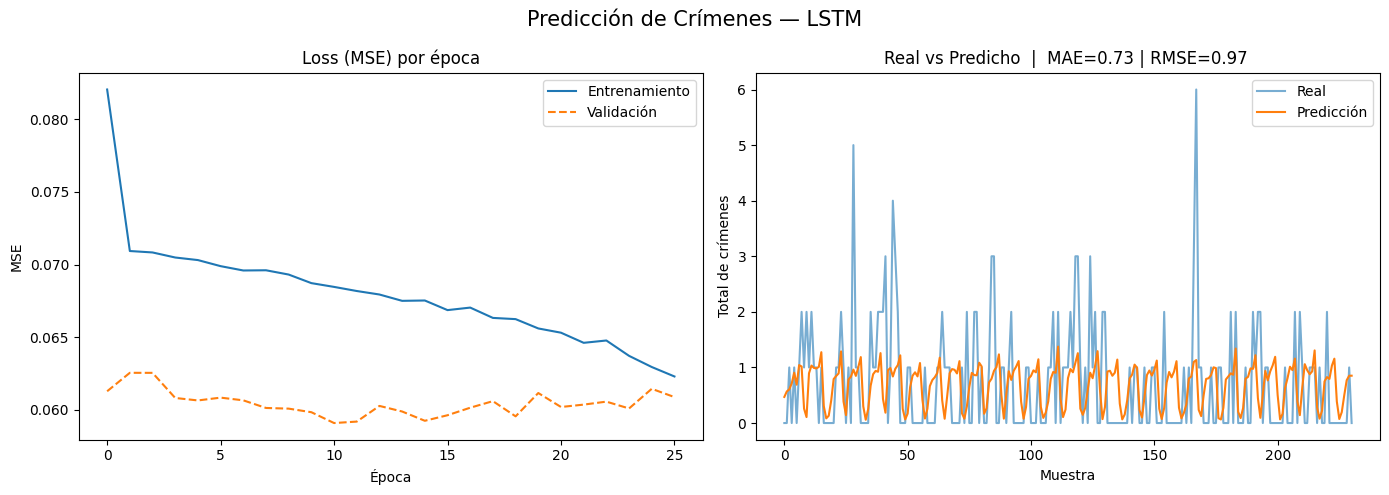

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Predicción de Crímenes — LSTM", fontsize=15)

axes[0].plot(history1.history['loss'],     label='Entrenamiento')
axes[0].plot(history1.history['val_loss'], label='Validación', linestyle='--')
axes[0].set_title("Loss (MSE) por época")
axes[0].set_xlabel("Época")
axes[0].set_ylabel("MSE")
axes[0].legend()

axes[1].plot(y_real1,  label='Real', alpha=0.6)
axes[1].plot(y_pred1,  label='Predicción')
axes[1].set_title(f"Real vs Predicho  |  MAE={mae1:.2f} | RMSE={rmse1:.2f} ")
axes[1].set_xlabel("Muestra")
axes[1].set_ylabel("Total de crímenes")
axes[1].legend()

plt.tight_layout()

### Seleccionando variables mas correlacionadas

In [20]:
correlaciones = df_final.corr()['Conteo']
columnas_seleccionadas = correlaciones[abs(correlaciones) >= 0.2].index.tolist()
columnas_seleccionadas

['Conteo',
 'Delito_ASALTO',
 'Delito_HURTO',
 'Delito_ROBO',
 'Delito_Sin delitos',
 'Victima_EDIFICACION',
 'Victima_PERSONA',
 'Victima_Sin delitos',
 'Edad_Mayor de edad',
 'Edad_Sin delitos',
 'Sexo_HOMBRE',
 'Sexo_MUJER',
 'Sexo_Sin delitos',
 'Nacionalidad_COSTA RICA',
 'Nacionalidad_Sin delitos',
 'Canton_CARTAGO',
 'Canton_Otros',
 'Canton_Sin delitos']

In [21]:
X_raw = df_final[columnas_seleccionadas].drop(columns=['Conteo']).values
y_raw = df_final['Conteo'].values.reshape(-1, 1)

n_raw     = len(X_raw)

remaining = n_raw - test_size
train_end = int(remaining * 0.80)

X_train_raw = X_raw[:train_end]
X_val_raw   = X_raw[train_end:remaining]
X_test_raw  = X_raw[remaining:]

y_train_raw = y_raw[:train_end]
y_val_raw   = y_raw[train_end:remaining]
y_test_raw  = y_raw[remaining:]

scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()

X_train_sc = scaler_X.fit_transform(X_train_raw)
y_train_sc = scaler_y.fit_transform(y_train_raw)

X_val_sc   = scaler_X.transform(X_val_raw)
y_val_sc   = scaler_y.transform(y_val_raw)

X_test_sc  = scaler_X.transform(X_test_raw)
y_test_sc  = scaler_y.transform(y_test_raw)

train_gen = TimeseriesGenerator(
    X_train_sc, y_train_sc,
    length=ventana,
    batch_size=32
)

val_gen = TimeseriesGenerator(
    X_val_sc, y_val_sc,
    length=ventana,
    batch_size=32
)

test_gen = TimeseriesGenerator(
    X_test_sc, y_test_sc,
    length=ventana,
    batch_size=32
)

modelo2 = Sequential([
    LSTM(100, return_sequences=True, input_shape=(ventana, X_train_sc.shape[1])),
    LSTM(50),
    Dropout(0.2),
    Dense(1, activation='softplus')
])

modelo2.compile(optimizer='adam', loss='mae', metrics=['mae'])


history2 = modelo2.fit(
    train_gen,
    validation_data=val_gen,
    epochs=60,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/60


c:\Users\mecag\.pyenv\pyenv-win\versions\3.11.9\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


227/227 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - loss: 0.0861 - mae: 0.0861 - val_loss: 0.0612 - val_mae: 0.0612
Epoch 2/60
227/227 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0711 - mae: 0.0711 - val_loss: 0.0612 - val_mae: 0.0612
Epoch 3/60
227/227 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0711 - mae: 0.0711 - val_loss: 0.0616 - val_mae: 0.0616
Epoch 4/60
227/227 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0710 - mae: 0.0710 - val_loss: 0.0618 - val_mae: 0.0618
Epoch 5/60
227/227 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0710 - mae: 0.0710 - val_loss: 0.0616 - val_mae: 0.0616
Epoch 6/60
227/227 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0706 - mae: 0.0706 - val_loss: 0.0614 - val_mae: 0.0614
Epoch 7/60
227/227 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.0706 - mae: 0.0706 - val_loss: 0.0614 - val_mae: 0.0614
Epoch 8/60
227/227 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.0709 - mae: 0.0709 - val_loss: 0.0613 - val_mae: 0.0613
Epoch 9/60
227/227 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0708 

In [22]:
y_pred2    = scaler_y.inverse_transform(modelo2.predict(test_gen))
y_real2   = scaler_y.inverse_transform(y_test_sc[ventana:])

rmse2 = np.sqrt(mean_squared_error(y_real2, y_pred2))
mae2 = mean_absolute_error(y_real2, y_pred2)
print(f'MAE: {mae2} | RMSE: {rmse2}')

8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step
MAE: 0.7804938879880038 | RMSE: 0.9979382591427663


### Todas las provincias

In [ ]:
provincias = df_agrupado['Provincia'].unique().tolist()
provincias.remove('DESCONOCIDO')

resultados = {}

for provincia in provincias:
    
    df_completo = rellenar_zona(df_agrupado[df_agrupado['Provincia'] == provincia].drop(columns='Provincia'))

    umbrales = {
        'Nacionalidad': 0.03,
        'Canton': 0.05,
    }

    df_completo = agrupar_infrecuentes(df_completo, umbrales)
    df_completo = crear_variables_temporales(df_completo, shift=9)
    df_completo = crear_ciclos(df_completo)


    vars_climaticas = obtener_variables_climaticas(
        latitude=provincias_coordenadas[provincia]["lat"],
        longitude=provincias_coordenadas[provincia]["lon"],
        start_date=df_completo['Fecha'].min().strftime('%Y-%m-%d'),
        end_date=df_completo['Fecha'].max().strftime('%Y-%m-%d'),
        variables=["precipitation", "apparent_temperature",'sunshine_duration'],
        interval_hours=3
    )

    df_final = pd.concat([df_completo.reset_index(drop=True), vars_climaticas[:-1].reset_index(drop=True)], axis=1)

    df_final = pd.get_dummies(df_final.drop(columns=['Distrito', 'SubDelito','SubVictima','Fecha', 'dia_sem','dia']))

    X_raw = df_final.drop(columns=['Conteo']).values
    y_raw = df_final['Conteo'].values.reshape(-1, 1)

    n_raw     = len(X_raw)

    remaining = n_raw - test_size
    train_end = int(remaining * 0.80)

    X_train_raw = X_raw[:train_end]
    X_val_raw   = X_raw[train_end:remaining]
    X_test_raw  = X_raw[remaining:]

    y_train_raw = y_raw[:train_end]
    y_val_raw   = y_raw[train_end:remaining]
    y_test_raw  = y_raw[remaining:]

    scaler_X = MinMaxScaler()
    scaler_y = MinMaxScaler()

    X_train_sc = scaler_X.fit_transform(X_train_raw)
    y_train_sc = scaler_y.fit_transform(y_train_raw)

    X_val_sc   = scaler_X.transform(X_val_raw)
    y_val_sc   = scaler_y.transform(y_val_raw)

    X_test_sc  = scaler_X.transform(X_test_raw)
    y_test_sc  = scaler_y.transform(y_test_raw)

    train_gen = TimeseriesGenerator(
        X_train_sc, y_train_sc,
        length=ventana,
        batch_size=32
    )

    val_gen = TimeseriesGenerator(
        X_val_sc, y_val_sc,
        length=ventana,
        batch_size=32
    )

    test_gen = TimeseriesGenerator(
        X_test_sc, y_test_sc,
        length=ventana,
        batch_size=32
    )

    modelo_final = Sequential([
        LSTM(100, return_sequences=True, input_shape=(ventana, X_train_sc.shape[1])),
        LSTM(50),
        Dropout(0.2),
        Dense(1, activation='softplus')
    ])

    modelo_final.compile(optimizer='adam', loss='mae', metrics=['mae'])

    history1 = modelo_final.fit(
        train_gen,
        validation_data=val_gen,
        epochs=60,
        callbacks=[early_stop],
        verbose=1
    )

    y_pred_final    = scaler_y.inverse_transform(modelo_final.predict(test_gen))
    y_real_final   = scaler_y.inverse_transform(y_test_sc[ventana:])

    rmse_final = np.sqrt(mean_squared_error(y_real_final, y_pred_final))
    mae_final = mean_absolute_error(y_real_final, y_pred_final)
    print(f'{provincia} -> MAE: {mae1:.4f} | RMSE: {rmse_final:.4f}')

    resultados[provincia] = {
        'MAE': mae_final,
        'RMSE': rmse_final
    }

    modelo_final.save(f'../src/models/LSTM-{provincia}.h5')

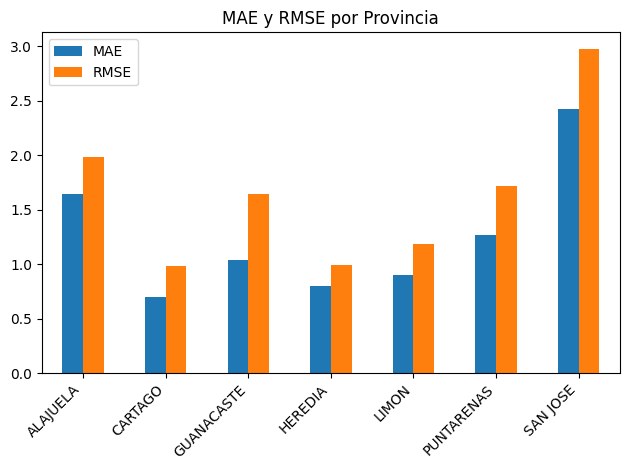

In [24]:
df_resultados = pd.DataFrame(resultados).T

df_resultados.plot(kind='bar', title='MAE y RMSE por Provincia')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Los resultados muestran como el modelo capta bien la tendencia general horaria, sin embargo, le es dificil predecir los eventos atipicos.